# FleetDAO — Notebook de Consultas y Operaciones DAO
### Proyecto Integrador · Bases de Datos II (2026)
**Autor:** Alesandro David Fajardo Torres

Este cuaderno demuestra el funcionamiento integral del **Patrón Data Access Object (DAO)** mediante la clase `FleetDAO`, la cual abstrae y centraliza las consultas a **MongoDB**, **Redis** y **MinIO**.

---
## 1. Conexión e Inicialización de la Capa DAO

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dao import FleetDAO

# Instanciación de la capa DAO
dao = FleetDAO()
print("✅ Conexión exitosa a MongoDB, Redis y MinIO a través de FleetDAO.")

2026-07-23 18:50:50,434 - INFO - Conexión exitosa a MongoDB, Redis y MinIO.


✅ Conexión exitosa a MongoDB, Redis y MinIO a través de FleetDAO.


---
## 2. Gestión de Entidades Maestras (Trucks & Drivers)
Consultamos los camiones y choferes almacenados en la base de datos y los estructuramos en DataFrames de Pandas.

In [2]:
# 2.1 Obtención de Camiones
trucks = dao.get_trucks()
df_trucks = pd.DataFrame(trucks)

if not df_trucks.empty:
    df_trucks['_id'] = df_trucks['_id'].astype(str)
    print(f"Total camiones registrados: {len(df_trucks)}")
    display(df_trucks[['_id', 'brand', 'capacity_tons']])
else:
    print("No hay camiones en la base de datos.")

Total camiones registrados: 8


,_id,brand,capacity_tons
0,6a628c9768b630f6d0c64b47,Volvo FH16,25.5
1,6a628c9768b630f6d0c64b48,Mercedes-Benz Actros,30.0
2,6a628c9768b630f6d0c64b49,Scania R450,18.0
3,6a628c9768b630f6d0c64b4a,Iveco Stralis,22.0
4,6a628c9768b630f6d0c64b4b,Ford Cargo 1723,17.5
5,6a628c9768b630f6d0c64b4c,MAN TGX 26.480,28.0
6,6a628c9768b630f6d0c64b4d,Renault T High,24.0
7,6a628c9768b630f6d0c64b4e,Volkswagen Constellation,19.0


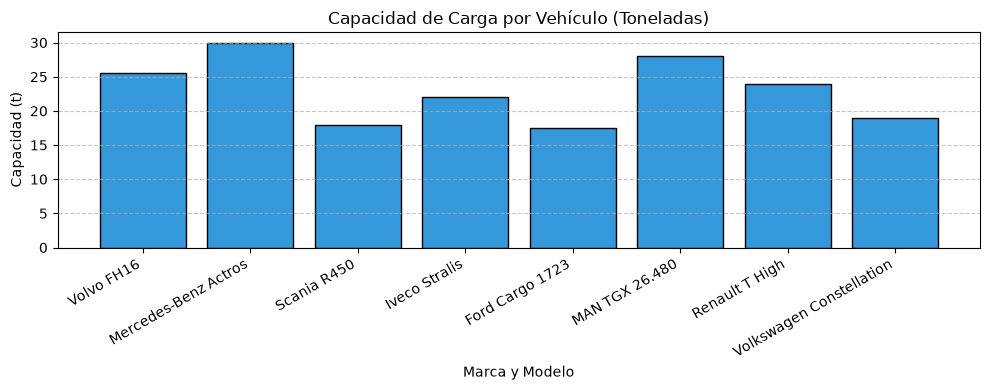

In [3]:
# 2.2 Visualización: Capacidad de Carga por Marca
if not df_trucks.empty:
    plt.figure(figsize=(10, 4))
    plt.bar(df_trucks['brand'], df_trucks['capacity_tons'], color='#3498db', edgecolor='black')
    plt.title('Capacidad de Carga por Vehículo (Toneladas)')
    plt.xlabel('Marca y Modelo')
    plt.ylabel('Capacidad (t)')
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

,_id,name,license_level
0,6a628c9768b630f6d0c64b4f,Juan Perez,A
1,6a628c9768b630f6d0c64b50,Maria Gonzalez,B
2,6a628c9768b630f6d0c64b51,Carlos Rodriguez,A
3,6a628c9768b630f6d0c64b52,Ana Martinez,B
4,6a628c9768b630f6d0c64b53,Roberto Fernandez,A
5,6a628c9768b630f6d0c64b54,Laura Benitez,B
6,6a628c9768b630f6d0c64b55,Diego Gomez,A
7,6a628c9768b630f6d0c64b56,Sofia Lopez,B


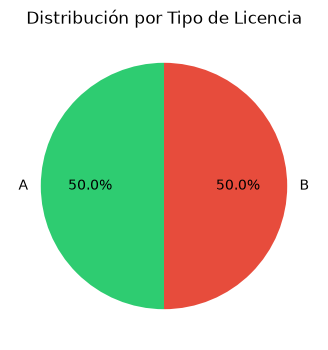

In [4]:
# 2.3 Obtención de Conductores y Niveles de Licencia
drivers = dao.get_drivers()
df_drivers = pd.DataFrame(drivers)

if not df_drivers.empty:
    df_drivers['_id'] = df_drivers['_id'].astype(str)
    display(df_drivers[['_id', 'name', 'license_level']])
    
    # Gráfico de distribución de licencias
    plt.figure(figsize=(5, 4))
    df_drivers['license_level'].value_counts().plot(
        kind='pie', autopct='%1.1f%%', startangle=90,
        colors=['#2ecc71', '#e74c3c', '#f1c40f']
    )
    plt.title('Distribución por Tipo de Licencia')
    plt.ylabel('')
    plt.show()

---
## 3. Consultas de Rutas Logísticas
Analizamos las asignaciones de rutas entre orígenes, destinos, camiones y choferes.

In [5]:
routes = dao.get_routes()
df_routes = pd.DataFrame(routes)

if not df_routes.empty:
    df_routes['_id'] = df_routes['_id'].astype(str)
    print(f"Total rutas logísticas activas: {len(df_routes)}")
    display(df_routes[['_id', 'origin', 'destination', 'truck_id', 'driver_id']])
else:
    print("No hay rutas registradas.")

Total rutas logísticas activas: 8


,_id,origin,destination,truck_id,driver_id
0,6a628c9768b630f6d0c64b57,Buenos Aires,Cordoba,6a628c9768b630f6d0c64b47,6a628c9768b630f6d0c64b4f
1,6a628c9768b630f6d0c64b58,Rosario,Mendoza,6a628c9768b630f6d0c64b48,6a628c9768b630f6d0c64b50
2,6a628c9768b630f6d0c64b59,Cordoba,Tucuman,6a628c9768b630f6d0c64b49,6a628c9768b630f6d0c64b51
3,6a628c9768b630f6d0c64b5a,Mendoza,La Rioja (Chilecito),6a628c9768b630f6d0c64b4a,6a628c9768b630f6d0c64b52
4,6a628c9768b630f6d0c64b5b,Salta,Jujuy,6a628c9768b630f6d0c64b4b,6a628c9768b630f6d0c64b53
5,6a628c9768b630f6d0c64b5c,Buenos Aires,Mar del Plata,6a628c9768b630f6d0c64b4c,6a628c9768b630f6d0c64b54
6,6a628c9768b630f6d0c64b5d,Neuquen,Bariloche,6a628c9768b630f6d0c64b4d,6a628c9768b630f6d0c64b55
7,6a628c9768b630f6d0c64b5e,Santa Fe,Corrientes,6a628c9768b630f6d0c64b4e,6a628c9768b630f6d0c64b56


---
## 4. Agregaciones de Telemetría (Aggregation Pipelines en MongoDB)
Usamos el método `get_truck_statistics()` del DAO que ejecuta un pipeline `$group` en MongoDB.

In [6]:
if not df_trucks.empty:
    first_truck_id = df_trucks.iloc[0]['_id']
    first_truck_name = df_trucks.iloc[0]['brand']
    
    stats = dao.get_truck_statistics(first_truck_id)
    print(f"📊 Estadísticas calculadas en MongoDB para {first_truck_name} (ID: {first_truck_id}):")
    print(f"  • Total lecturas de telemetría: {stats.get('total_lecturas')}")
    print(f"  • Velocidad Promedio: {stats.get('velocidad_promedio', 0):.2f} km/h")
    print(f"  • Temperatura Máxima del Motor: {stats.get('temp_maxima', 0):.2f} °C")
    print(f"  • Combustible Promedio: {stats.get('combustible_promedio', 0):.2f} %")

📊 Estadísticas calculadas en MongoDB para Volvo FH16 (ID: 6a628c9768b630f6d0c64b47):
  • Total lecturas de telemetría: 100
  • Velocidad Promedio: 80.17 km/h
  • Temperatura Máxima del Motor: 115.00 °C
  • Combustible Promedio: 91.52 %


---
## 5. Consultas Geoespaciales (Índices `2dsphere` y Geocercas)
Consultamos las geocercas registradas y ejecutamos búsquedas por proximidad ($near).

In [7]:
geofences = dao.get_geofences()
print(f"🗺️ Total geocercas espaciales encontradas: {len(geofences)}")
for gf in geofences:
    print(f"  • Geocerca: '{gf.get('name')}' (Camión ID: {gf.get('truck_id')})")

🗺️ Total geocercas espaciales encontradas: 4
  • Geocerca: 'Geocerca Zona Centro (BA - Cba)' (Camión ID: 6a628c9768b630f6d0c64b47)
  • Geocerca: 'Geocerca Zona Cuyo (Mendoza - La Rioja)' (Camión ID: 6a628c9768b630f6d0c64b4a)
  • Geocerca: 'Geocerca Zona Norte (Tucumán - Salta)' (Camión ID: 6a628c9768b630f6d0c64b4b)
  • Geocerca: 'Geocerca Zona Patagonia (Neuquén - Bariloche)' (Camión ID: 6a628c9768b630f6d0c64b4d)


---
## 6. Demostración de Caché en Tiempo Real (Redis)
Consultamos la última posición en caché O(1) utilizando Redis mediante `get_latest_telemetry_cache()`.

In [8]:
if not df_trucks.empty:
    cache_data = dao.get_latest_telemetry_cache(truck_id=first_truck_id)
    if cache_data:
        print(f"⚡ Lectura desde Redis en O(1) para camión {first_truck_id}:")
        print(cache_data)
    else:
        print(f"No hay caché en Redis para el camión {first_truck_id} (ejecute simulator.py si desea ver lecturas en vivo).")

⚡ Lectura desde Redis en O(1) para camión 6a628c9768b630f6d0c64b47:
{'speed_kmh': 46.2, 'engine_rpm': 1736, 'engine_temp_c': 94.81, 'fuel_level_pct': 87.47, 'lon': -64.18291, 'lat': -31.42395, 'timestamp': '2026-07-23T20:29:15.680607'}


---
## 7. Cierre de Conexiones
Liberamos los recursos de conexión con MongoDB y Redis.

In [9]:
dao.close()
print("🔒 Conexiones cerradas de manera segura.")

2026-07-23 18:50:50,852 - INFO - Conexión a MongoDB cerrada de manera segura.


🔒 Conexiones cerradas de manera segura.
